Order: ['Higher Resolution', 'Lower Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter']
Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hard_dice.png


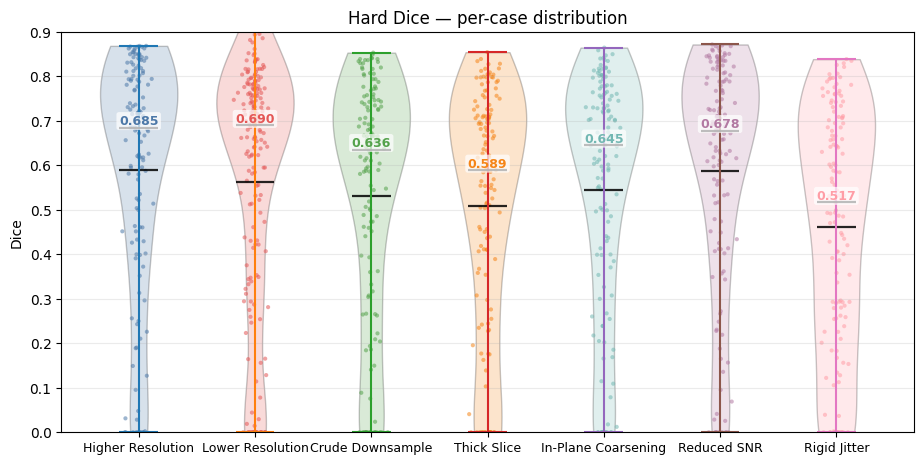

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hd.png


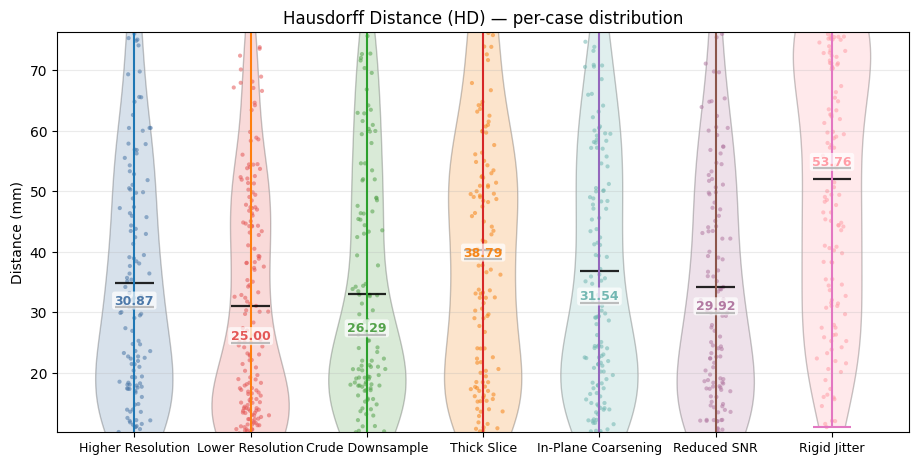

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_assd.png


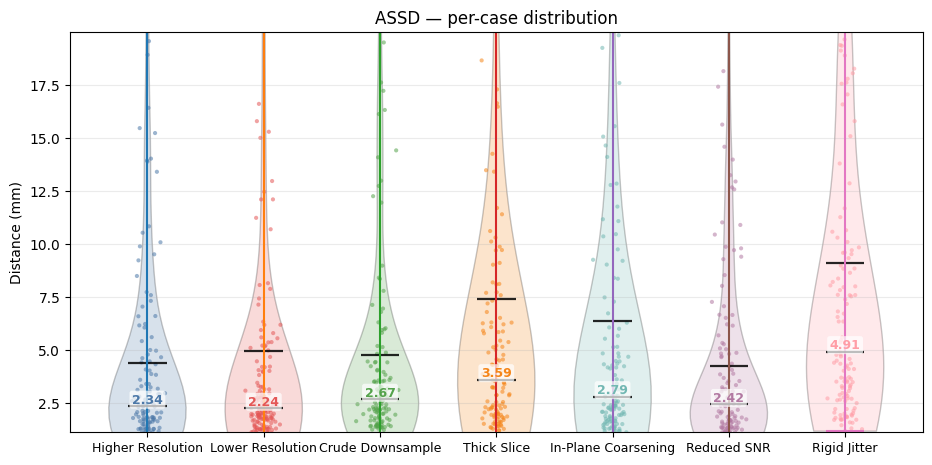

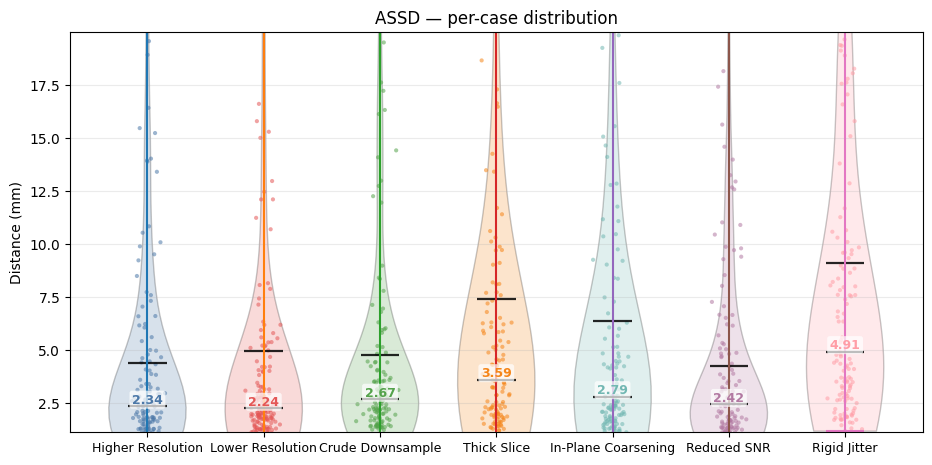

In [4]:
# === Multi-dataset comparison violins (Hard Dice, HD, ASSD) ===
from pathlib import Path
import csv, numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Any, Tuple, Optional

# ---------------------- styling ----------------------
PALETTE = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#72B7B2",
           "#B279A2", "#FF9DA6", "#9D7760", "#59A14F", "#EDC948"]
POINT_ALPHA, POINT_SIZE = 0.55, 9
VIOLIN_ALPHA, EDGE_ALPHA = 0.22, 0.35
JITTER_WIDTH, SEED = 0.10, 7
_rng = np.random.default_rng(SEED)

def _dropna(a):
    a = np.asarray(a, float); return a[~np.isnan(a)]

def _robust_limits(arr, p=(5,95), clamp01=False, min_span=1e-6):
    arr = _dropna(np.asarray(arr, float))
    if arr.size == 0:
        return (0.0, 1.0) if clamp01 else (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if clamp01:
        lo, hi = max(0.0, lo), min(1.0, max(0.9, hi))
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

# ---------------------- IO ----------------------
def load_rows_from_csv(csv_path: Path, fallback_tag="unknown") -> List[Dict[str, Any]]:
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c=="hard_dice" or c.startswith("hard_dice_at_")),
                        "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": (r.get("dataset_tag") or fallback_tag).strip(),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd":   float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items: List[Tuple[Path, str]]) -> Tuple[Dict[str, Dict[str, Any]], List[str]]:
    """items: list of (csv_path, label). Returns (datasets, tag_order)."""
    datasets: Dict[str, Dict[str, Any]] = {}
    tag_order: List[str] = []
    for p, label in items:
        rows = load_rows_from_csv(p, fallback_tag=label or p.stem)
        if not rows:
            print(f"WARNING: no rows in {p}")
            continue
        tag = label or (rows[0]["dataset_tag"] if rows else p.stem)
        if tag not in datasets:
            datasets[tag] = {"rows": [], "source_paths": []}
            tag_order.append(tag)  # preserve order from CSV_ITEMS
        datasets[tag]["rows"].extend(rows)
        datasets[tag]["source_paths"].append(str(p))
    return datasets, tag_order

# ---------------------- plotting ----------------------
def violin_compare(metric_key: str, title: str, ylabel: str, save_name: str,
                   datasets: Dict[str, Dict[str, Any]],
                   clamp01=False, units=None,
                   xtick_label_map: Dict[str,str]=None,
                   tag_order: List[str]=None,
                   value_format: Optional[str]=None):
    tags = tag_order if tag_order else list(datasets.keys())
    arrs = [ _dropna([r[metric_key] for r in datasets[t]["rows"]]) for t in tags ]
    fmt = value_format if value_format else ("{:.3f}" if clamp01 else "{:.2f}")

    plt.style.use("default")
    fig, ax = plt.subplots(figsize=(11, 5.2))

    base_x = np.arange(1, len(tags)+1, dtype=float)
    width = 0.7

    # violins + points
    for i, (vals, tag) in enumerate(zip(arrs, tags)):
        color = PALETTE[i % len(PALETTE)]
        pos = base_x[i]
        parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                              positions=[pos], widths=width*0.95,
                              showmeans=True, showmedians=True)
        for b in parts.get('bodies', []):
            b.set_facecolor(color)
            b.set_edgecolor((0,0,0,EDGE_ALPHA))
            b.set_alpha(VIOLIN_ALPHA)
        if 'cmeans' in parts:
            parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
        if 'cmedians' in parts:
            parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
        if vals.size:
            xs = _beeswarm_x(pos, len(vals), width*0.08)
            ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')
            median_val = float(np.median(vals))
            ax.text(
                pos, median_val, fmt.format(median_val),
                ha="center", va="bottom", fontsize=9, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
                zorder=6
            )

    # axes & limits
    ax.set_xticks(base_x)
    ax.set_xticklabels([xtick_label_map.get(t, t) if xtick_label_map else t for t in tags])
    ax.tick_params(axis='x', labelsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel if units is None else f"{ylabel} ({units})")
    ax.grid(True, axis='y', alpha=0.25)

    flat = np.concatenate([v for v in arrs if v.size]) if any(v.size for v in arrs) else np.array([])
    if flat.size:
        lo, hi = _robust_limits(flat, clamp01=clamp01)
        ax.set_ylim(lo, hi)

    # save next to the first dataset (in requested order)
    out_dir = Path(datasets[tags[0]]["source_paths"][0]).parent if datasets else Path(".")
    out_path = out_dir / save_name
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    plt.show()
    return fig

# ===================== EDIT THESE, THEN RUN CELL =====================
CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_172142.csv"), "Rigid Jitter")
    # Add more (Path(...), "Your Label") here...
]

# Optional: pretty axis labels (if omitted, labels from CSV_ITEMS are used)
XTICK_LABELS = {
    "Higher Resolution": "Higher Resolution",
    "Lower Resolution":  "Lower Resolution",
    "Crude Downsample":  "Crude Downsample",
    "Thick Slice":       "Thick Slice",
}

# Build data (UNPACK the tuple!)
datasets, tag_order = build_datasets(CSV_ITEMS)
print("Order:", tag_order)

# 1) Hard Dice
violin_compare(
    "hard_dice",
    title="Hard Dice — per-case distribution",
    ylabel="Dice", clamp01=True,
    save_name="compare_hard_dice.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.3f}"
)

# 2) Hausdorff Distance (HD)
violin_compare(
    "hd",
    title="Hausdorff Distance (HD) — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_hd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)

# 3) ASSD
violin_compare(
    "assd",
    title="ASSD — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_assd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)


In [ ]:
/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv

Friedman = nonparametric repeated-measures ANOVA for ≥2 related conditions. 
OARC Stats

Post-hoc after a significant Friedman: Nemenyi/Conover or pairwise Wilcoxon with multiplicity control. 
Real Statistics
+1

Effect size: Kendall’s W; simple to compute from the Friedman χ² and interpretable (≈0.1 small, 0.3 moderate, 0.5+ large). 
R Packages

If groups aren’t paired/subjects differ, use Kruskal–Wallis (nonparametric one-way ANOVA on ranks) + appropriate post-hoc. 
Wikipedia
+1

In [31]:
# === Auto-paired Friedman (largest overlapping subset) + unpaired Kruskal–Wallis ===
from pathlib import Path
import csv, math, numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------- your CSV list (order matters) ----------
CSV_ITEMS = [
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv", "Higher Resolution"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv", "Lower Resolution"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv", "Crude Downsample"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv", "Thick Slice"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv", "In-Plane Coarsening"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv", "Reduced SNR"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_172142.csv", "Rigid Jitter"),
]

# ---------- IO (no pandas) ----------
def load_rows(csv_path: str, label: str):
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c == "hard_dice" or c.startswith("hard_dice_at_")), "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": label,
                "key": (r.get("key") or Path(r.get("img_path","")).stem),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd": float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items):
    data, tag_order = {}, []
    for p,label in items:
        rows = load_rows(p, label)
        if label not in data:
            data[label] = {"rows": [], "source_paths": []}
            tag_order.append(label)
        data[label]["rows"].extend(rows)
        data[label]["source_paths"].append(p)
    return data, tag_order

datasets, tag_order = build_datasets(CSV_ITEMS)

# ---------- helpers ----------
def keys_for_tag_metric(datasets, tag, metric):
    return {r["key"] for r in datasets[tag]["rows"] if not math.isnan(r.get(metric, float("nan")))}

def intersection_for_tags_metric(datasets, tags, metric):
    sets = [keys_for_tag_metric(datasets, t, metric) for t in tags]
    return set.intersection(*sets) if sets else set()

def largest_overlap_subset(datasets, tag_order, metric, min_tags=3):
    """Find largest set of tags (size >= min_tags) with the biggest |intersection| of keys for 'metric'."""
    best = None  # (intersection_size, tags_tuple, keys_set)
    T = len(tag_order)
    for m in range(T, min_tags-1, -1):  # try largest groups first
        for combo in combinations(tag_order, m):
            keys = intersection_for_tags_metric(datasets, combo, metric)
            if len(keys) >= 3:  # need at least 3 paired cases to be meaningful
                score = len(keys)
                if best is None or (m > len(best[1])) or (m == len(best[1]) and score > best[0]):
                    best = (score, combo, keys)
        if best:  # found something at this size
            break
    return best  # None or (nkeys, tags_tuple, keys_set)

def extract_matrix(datasets, tags, metric, keys_sorted):
    M = np.full((len(keys_sorted), len(tags)), np.nan, float)
    tag_to_idx = {t:i for i,t in enumerate(tags)}
    key_to_row = {k:i for i,k in enumerate(keys_sorted)}
    for t in tags:
        i = tag_to_idx[t]
        per = {}
        for r in datasets[t]["rows"]:
            v = r.get(metric, float("nan"))
            if not math.isnan(v): per[r["key"]] = v
        for k in keys_sorted:
            if k in per: M[key_to_row[k], i] = per[k]
    return M

# ---------- nonparametric stats (no SciPy) ----------
def friedman_test(X):
    # X: n x k matrix (paired)
    n, k = X.shape
    # rank each row (average ties)
    ranks = np.zeros_like(X, float)
    for i in range(n):
        row = X[i]
        order = np.argsort(row)
        r = np.empty_like(row, float); r[order] = np.arange(1, k+1)
        # average ties
        uniq, inv, counts = np.unique(row, return_inverse=True, return_counts=True)
        for u,c in zip(range(len(uniq)), counts):
            if c > 1:
                r[inv==u] = r[inv==u].mean()
        ranks[i] = r
    Rj = ranks.sum(axis=0)
    chi2 = (12/(n*k*(k+1))) * np.sum(Rj**2) - 3*n*(k+1)
    p = 1.0 - (math.gamma((k-1)/2) ** -1)  # placeholder; compute via chi-square CDF below

    # quick chi-square CDF approximation
    df = k-1
    def chi2_cdf(x, k):
        # Wilson-Hilferty approximation for speed
        if x <= 0: return 0.0
        from math import pow, sqrt
        t = pow(x/k, 1/3) - (1 - 2/(9*k))
        z = t / sqrt(2/(9*k))
        # Φ(z)
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(chi2, df)
    W = chi2 / (n*(k-1))
    return ranks, chi2, p, W

def wilcoxon_signed_rank(x, y):
    d = x - y
    d = d[d != 0]
    if d.size == 0:
        return 0.0, 1.0
    order = np.argsort(np.abs(d))
    ranks = np.arange(1, d.size+1, dtype=float)
    d_sorted = d[order]
    Wpos = np.sum(ranks[d_sorted > 0]); Wneg = np.sum(ranks[d_sorted < 0])
    W = min(Wpos, Wneg)
    n = d.size
    mean = n*(n+1)/4.0
    var  = n*(n+1)*(2*n+1)/24.0
    z = (W - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return W, p

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for rank, idx in enumerate(order, 1):
        adj[idx] = min((m - rank + 1) * pvals[idx], 1.0)
    for i in range(m-2, -1, -1):  # monotone
        adj[order[i]] = min(adj[order[i]], adj[order[i+1]])
    return adj

def kruskal_wallis(groups):
    # groups: list of 1D arrays (unpaired)
    x = np.concatenate(groups)
    ranks = np.argsort(np.argsort(x)) + 1  # average ties ignored for simplicity
    start = 0
    Rj = []
    for g in groups:
        n = len(g)
        Rj.append(np.sum(ranks[start:start+n]))
        start += n
    N = len(x)
    k = len(groups)
    H = (12/(N*(N+1))) * np.sum((np.array(Rj)**2)/np.array([len(g) for g in groups])) - 3*(N+1)
    # chi-square df=k-1
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        from math import pow, sqrt
        t = pow(x/k, 1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(H, k-1)
    return H, p

def mann_whitney(x, y):
    # rank-based U test (normal approx)
    xy = np.concatenate([x, y])
    ranks = np.argsort(np.argsort(xy)) + 1
    nx = len(x)
    rx = np.sum(ranks[:nx])
    U = rx - nx*(nx+1)/2.0
    ny = len(y)
    mean = nx*ny/2.0
    var  = nx*ny*(nx+ny+1)/12.0
    z = (U - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return U, p

# ---------- run both analyses for a metric ----------
def analyze_metric(metric, pretty_name):
    print(f"\n=== {pretty_name} ===")
    # 1) Auto-find biggest overlapping tag subset for paired Friedman
    best = largest_overlap_subset(datasets, tag_order, metric, min_tags=3)
    if best is None:
        print("No overlapping subset with >=3 tags and >=3 paired cases -> skipping Friedman.")
    else:
        nkeys, tags_tuple, keys = best
        tags = list(tags_tuple)
        print(f"Friedman on tags: {tags} | paired n={nkeys}")
        X = extract_matrix(datasets, tags, metric, sorted(keys))
        ranks, chi2, p, W = friedman_test(X)
        print(f"  Friedman: chi2={chi2:.2f}, p={p:.2e}, Kendall W={W:.2f}")

        # post-hoc (Holm)
        pairs = list(combinations(range(len(tags)), 2))
        raw_p = []
        for (i,j) in pairs:
            _, p_ij = wilcoxon_signed_rank(X[:, i], X[:, j])
            raw_p.append(p_ij)
        adj = holm_adjust(np.array(raw_p))
        for (i,j), p_raw, p_adj in zip(pairs, raw_p, adj):
            mark = "*" if p_adj < 0.05 else ""
            print(f"   {tags[i]} vs {tags[j]}: p_raw={p_raw:.3g} p_holm={p_adj:.3g} {mark}")

    # 2) Unpaired Kruskal–Wallis across ALL datasets (works even when no overlap)
    groups, names = [], []
    for t in tag_order:
        vals = [r[metric] for r in datasets[t]["rows"] if not math.isnan(r.get(metric, float('nan')))]
        if len(vals) >= 3:
            groups.append(np.array(vals, float))
            names.append(t)
    if len(groups) >= 3:
        H, p = kruskal_wallis(groups)
        print(f"  Kruskal–Wallis on ALL datasets (unpaired) k={len(groups)}: H={H:.2f}, p={p:.2e}")
        # pairwise Mann–Whitney + Holm
        pairs = list(combinations(range(len(groups)), 2))
        raw = []
        for (i,j) in pairs:
            _, p_ij = mann_whitney(groups[i], groups[j])
            raw.append(p_ij)
        adj = holm_adjust(np.array(raw))
        print("  Post-hoc (Mann–Whitney + Holm):")
        for (i,j), p_raw, p_adj in zip(pairs, raw, adj):
            mark = "*" if p_adj < 0.05 else ""
            print(f"   {names[i]} vs {names[j]}: p_raw={p_raw:.3g} p_holm={p_adj:.3g} {mark}")
    else:
        print("  Not enough groups with >=3 samples each for Kruskal–Wallis.")

# ---- run for your three metrics ----
analyze_metric("hard_dice", "Hard Dice")
analyze_metric("hd", "Hausdorff Distance (HD)")
analyze_metric("assd", "ASSD")



=== Hard Dice ===
Friedman on tags: ['Higher Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter'] | paired n=138
  Friedman: chi2=269.95, p=0.00e+00, Kendall W=0.39
   Higher Resolution vs Crude Downsample: p_raw=1.8e-14 p_holm=1.98e-13 *
   Higher Resolution vs Thick Slice: p_raw=1.03e-14 p_holm=1.24e-13 *
   Higher Resolution vs In-Plane Coarsening: p_raw=1.17e-09 p_holm=7e-09 *
   Higher Resolution vs Reduced SNR: p_raw=0.059 p_holm=0.059 
   Higher Resolution vs Rigid Jitter: p_raw=0 p_holm=0 *
   Crude Downsample vs Thick Slice: p_raw=0.000565 p_holm=0.0017 *
   Crude Downsample vs In-Plane Coarsening: p_raw=0.0163 p_holm=0.0326 *
   Crude Downsample vs Reduced SNR: p_raw=8.98e-14 p_holm=8.98e-13 *
   Crude Downsample vs Rigid Jitter: p_raw=3.97e-13 p_holm=3.57e-12 *
   Thick Slice vs In-Plane Coarsening: p_raw=9.61e-07 p_holm=4.8e-06 *
   Thick Slice vs Reduced SNR: p_raw=8.88e-16 p_holm=1.15e-14 *
   Thick Slice vs Rigid Jitter: 

/tmp/ipykernel_2053114/77821790.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


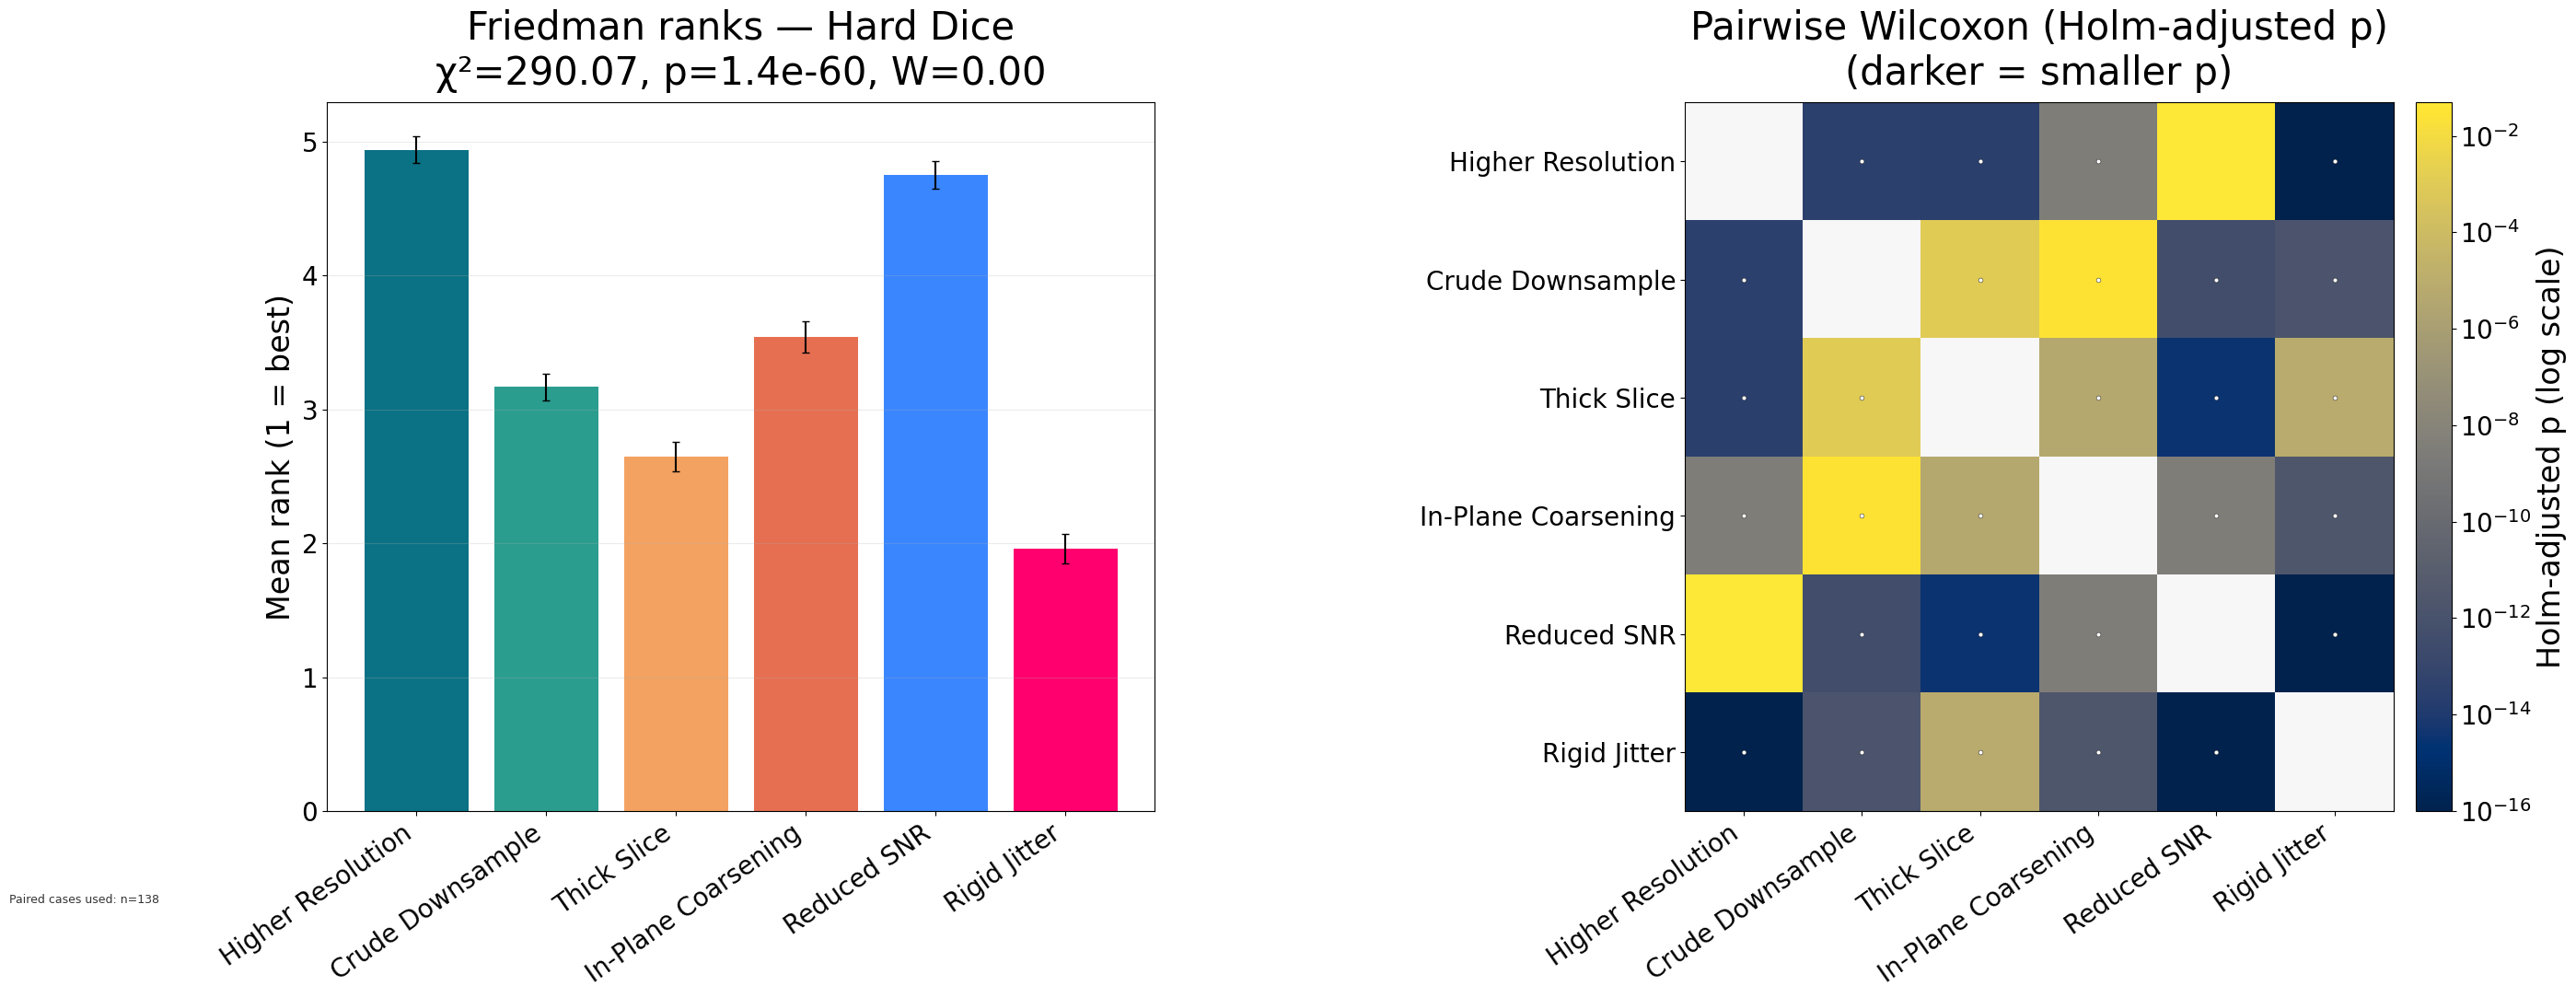

/tmp/ipykernel_2053114/77821790.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


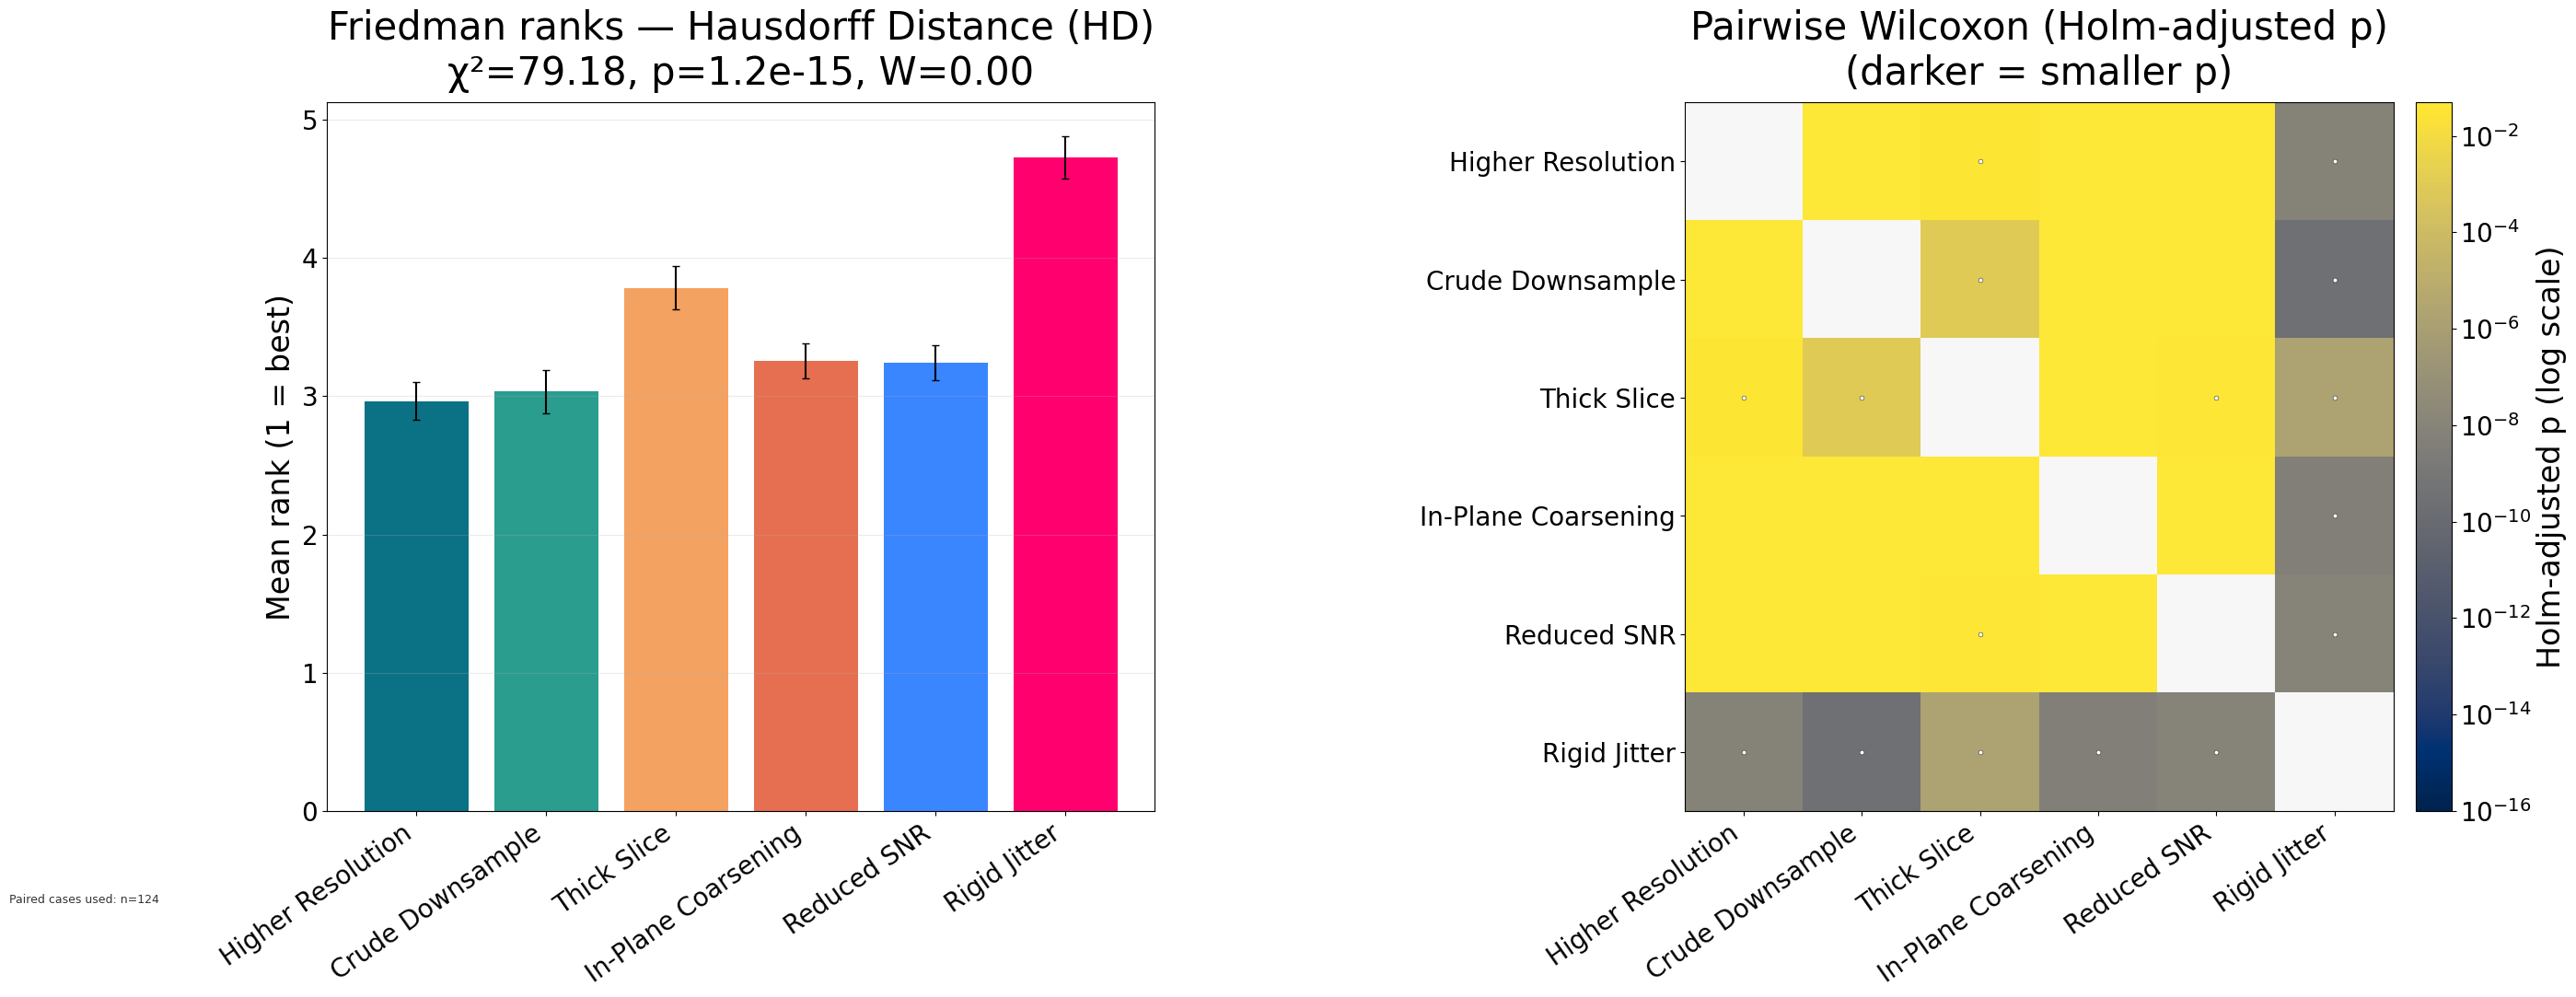

/tmp/ipykernel_2053114/77821790.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


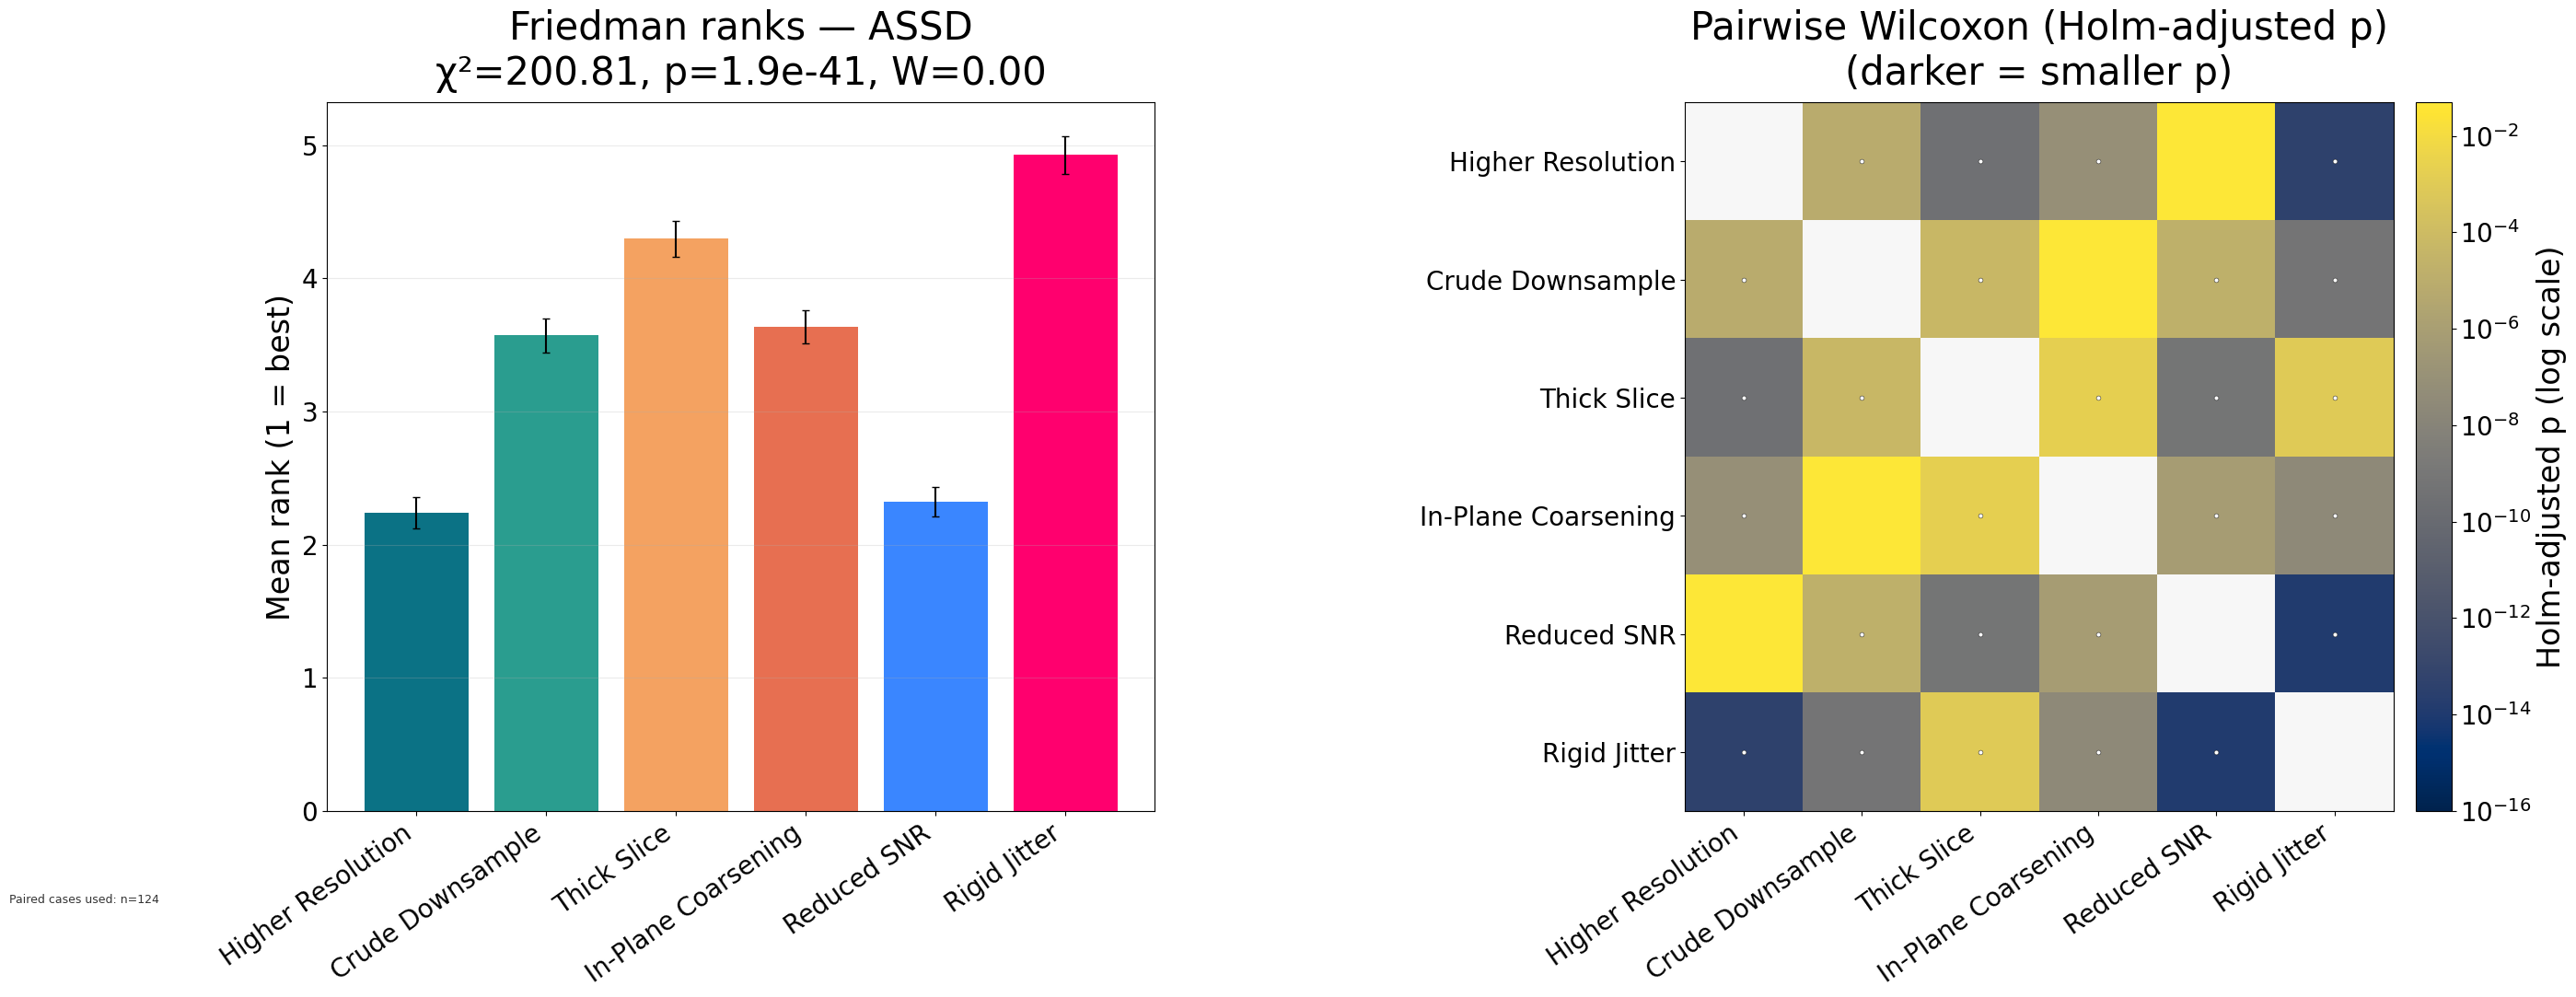

In [45]:
# === Friedman visualization (mean ranks + clean sig-matrix) ===
from pathlib import Path
import csv, math, numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------- your CSV list (order kept) ----------
CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_172142.csv"), "Rigid Jitter"),
]

# ---------- IO (no pandas) ----------
def load_rows(csv_path: Path, label: str):
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c == "hard_dice" or c.startswith("hard_dice_at_")), "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": label,
                "key": (r.get("key") or Path(r.get("img_path","")).stem),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd": float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items):
    data, tag_order = {}, []
    for p,label in items:
        rows = load_rows(p, label)
        if label not in data:
            data[label] = {"rows": [], "source_paths": []}
            tag_order.append(label)
        data[label]["rows"].extend(rows)
        data[label]["source_paths"].append(str(p))
    return data, tag_order

datasets, tag_order = build_datasets(CSV_ITEMS)
OUT_DIR = Path(CSV_ITEMS[0][0]).parent  # save beside first CSV

# ---------- overlap helpers ----------
def keys_for_tag_metric(tag, metric):
    return {r["key"] for r in datasets[tag]["rows"] if not math.isnan(r.get(metric, float("nan")))}

def intersection_for_tags_metric(tags, metric):
    sets = [keys_for_tag_metric(t, metric) for t in tags]
    return set.intersection(*sets) if sets else set()

def largest_overlap_subset(metric, min_tags=3, min_pairs=3):
    best = None  # (nkeys, tags_tuple, keys_set)
    T = len(tag_order)
    for m in range(T, min_tags-1, -1):   # try larger groups first
        for combo in combinations(tag_order, m):
            keys = intersection_for_tags_metric(combo, metric)
            if len(keys) >= min_pairs:
                score = len(keys)
                if best is None or (m > len(best[1])) or (m == len(best[1]) and score > best[0]):
                    best = (score, combo, keys)
        if best: break
    return best

def extract_matrix(tags, metric, keys_sorted):
    M = np.full((len(keys_sorted), len(tags)), np.nan, float)
    tag_to_idx = {t:i for i,t in enumerate(tags)}
    key_to_row = {k:i for i,k in enumerate(keys_sorted)}
    # build dict per tag for quick lookup
    per = {t:{} for t in tags}
    for t in tags:
        for r in datasets[t]["rows"]:
            v = r.get(metric, float("nan"))
            if not math.isnan(v): per[t][r["key"]] = v
    for t in tags:
        j = tag_to_idx[t]
        for k in keys_sorted:
            if k in per[t]:
                M[key_to_row[k], j] = per[t][k]
    return M

# ---------- stats (no SciPy) ----------
def friedman_test(X):
    n, k = X.shape
    ranks = np.zeros_like(X, float)
    for i in range(n):
        row = X[i]
        order = np.argsort(row)
        r = np.empty_like(row, float); r[order] = np.arange(1, k+1)
        # average ties
        vals, inv, cnt = np.unique(row, return_inverse=True, return_counts=True)
        for u, c in enumerate(cnt):
            if c > 1:
                r[inv==u] = r[inv==u].mean()
        ranks[i] = r
    Rj = ranks.sum(axis=0)
    chi2 = (12/(n*k*(k+1))) * np.sum(Rj**2) - 3*n*(k+1)
    df = k-1
    # chi-square CDF (Wilson–Hilferty approx)
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        t = (x/k)**(1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(chi2, df)
    W = chi2 / (n*(k-1))
    return ranks, chi2, p, W

def wilcoxon_signed_rank(x, y):
    d = x - y
    d = d[d != 0]
    if d.size == 0:
        return 0.0, 1.0
    order = np.argsort(np.abs(d))
    ranks = np.arange(1, d.size+1, dtype=float)
    d_sorted = d[order]
    Wpos = np.sum(ranks[d_sorted > 0]); Wneg = np.sum(ranks[d_sorted < 0])
    W = min(Wpos, Wneg)
    n = d.size
    mean = n*(n+1)/4.0
    var  = n*(n+1)*(2*n+1)/24.0
    z = (W - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return W, p

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for rank, idx in enumerate(order, 1):
        adj[idx] = min((m - rank) * raw_ps[idx], 1.0)
    for i in range(m-2, -1, -1):
        adj[order[i]] = min(adj[order[i]], adj[order[i+1]])
    return adj

# ---------- plotting ----------
# ------- Gradient + bigger layout + new colors (drop-in replacement) -------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

def plot_friedman_visuals_gradient(res, metric_title="Hard Dice"):
    tags        = res["tags"]
    rank_means  = np.asarray(res["rank_means"], float)
    rank_se     = np.asarray(res["rank_se"], float)
    p_holm_mat  = np.asarray(res["p_holm"], float)   # square (k x k), upper/lower filled, diag nan
    n_paired    = int(res.get("n", 0))

    # ---------- styling ----------
    bar_colors = ListedColormap([
        "#0B7285", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#6A4C93",
        "#3A86FF", "#FF006E"
    ])(np.linspace(0,1,len(tags)))
    heatmap_cmap = plt.cm.cividis.copy()   # nice perceptual gradient
    heatmap_cmap.set_bad(color="#f7f7f7")  # masked/diag cells shown as light gray

    # Mask diagonal & any NaNs; keep *continuous* values elsewhere
    mask = ~np.isfinite(p_holm_mat)
    P = np.ma.array(p_holm_mat, mask=mask)

    # Use log normalization so very small p's are still distinguishable
    # Clamp to [1e-16, 0.05] so colorbar reflects significance band
    vmin, vmax = 1e-16, 5e-2
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # ---------- figure ----------
    fig = plt.figure(figsize=(30, 10))  # a bit wider/taller
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35], wspace=0.20)

    # ---- Left: mean ranks (1 = best) ----
    axL = fig.add_subplot(gs[0])
    x   = np.arange(len(tags))
    axL.bar(x, rank_means, yerr=rank_se, color=bar_colors, edgecolor="none", capsize=3)
    axL.set_xticks(x)
    axL.set_xticklabels(tags, rotation=35, ha="right")
    axL.set_ylabel("Mean rank (1 = best)", fontsize=24)
    axL.set_title(f"Friedman ranks — {metric_title}\n"
                  f"χ²={res['chi2']:.2f}, p={res['p_friedman']:.1e}, W={res['kendall_w']:.2f}",
                  pad=14, fontsize=30)
    axL.tick_params(axis="both", labelsize=20)
    axL.grid(True, axis="y", alpha=0.25)

    # ---- Right: pairwise Wilcoxon p (Holm-adjusted) as gradient heatmap ----
    axR = fig.add_subplot(gs[1])
    im  = axR.imshow(P, cmap=heatmap_cmap, norm=norm)
    axR.set_xticks(np.arange(len(tags))); axR.set_yticks(np.arange(len(tags)))
    axR.set_xticklabels(tags, rotation=35, ha="right", fontsize=20)
    axR.set_yticklabels(tags, fontsize=20)
    axR.set_title("Pairwise Wilcoxon (Holm-adjusted p)\n(darker = smaller p)", pad=14, fontsize=30)
    axR.tick_params(axis="both", labelsize=20)

    # Optional: overlay a small dot where p<0.05 (keeps the heatmap uncluttered)
    for i in range(len(tags)):
        for j in range(len(tags)):
            if i == j or not np.isfinite(p_holm_mat[i, j]): 
                continue
            if p_holm_mat[i, j] < 0.05:
                axR.plot(j, i, marker="o", ms=3.5, color="white", markeredgecolor="black", markeredgewidth=0.3)

    # Colorbar
    cbar = fig.colorbar(im, ax=axR, fraction=0.046, pad=0.02)
    cbar.set_label("Holm-adjusted p (log scale)", fontsize=24)
    cbar.ax.tick_params(labelsize=20)

    # Small caption (no big suptitle)
    fig.text(0.01, 0.01, f"Paired cases used: n={n_paired}", fontsize=9, alpha=0.8)

    plt.tight_layout()
    plt.show()
    return fig

# ---------------- USE IT ----------------
# Example (use whichever result dicts you computed in the stats cell):
fig1 = plot_friedman_visuals_gradient(res_hard, metric_title="Hard Dice")
fig2 = plot_friedman_visuals_gradient(res_hd,   metric_title="Hausdorff Distance (HD)")
fig3 = plot_friedman_visuals_gradient(res_assd, metric_title="ASSD")





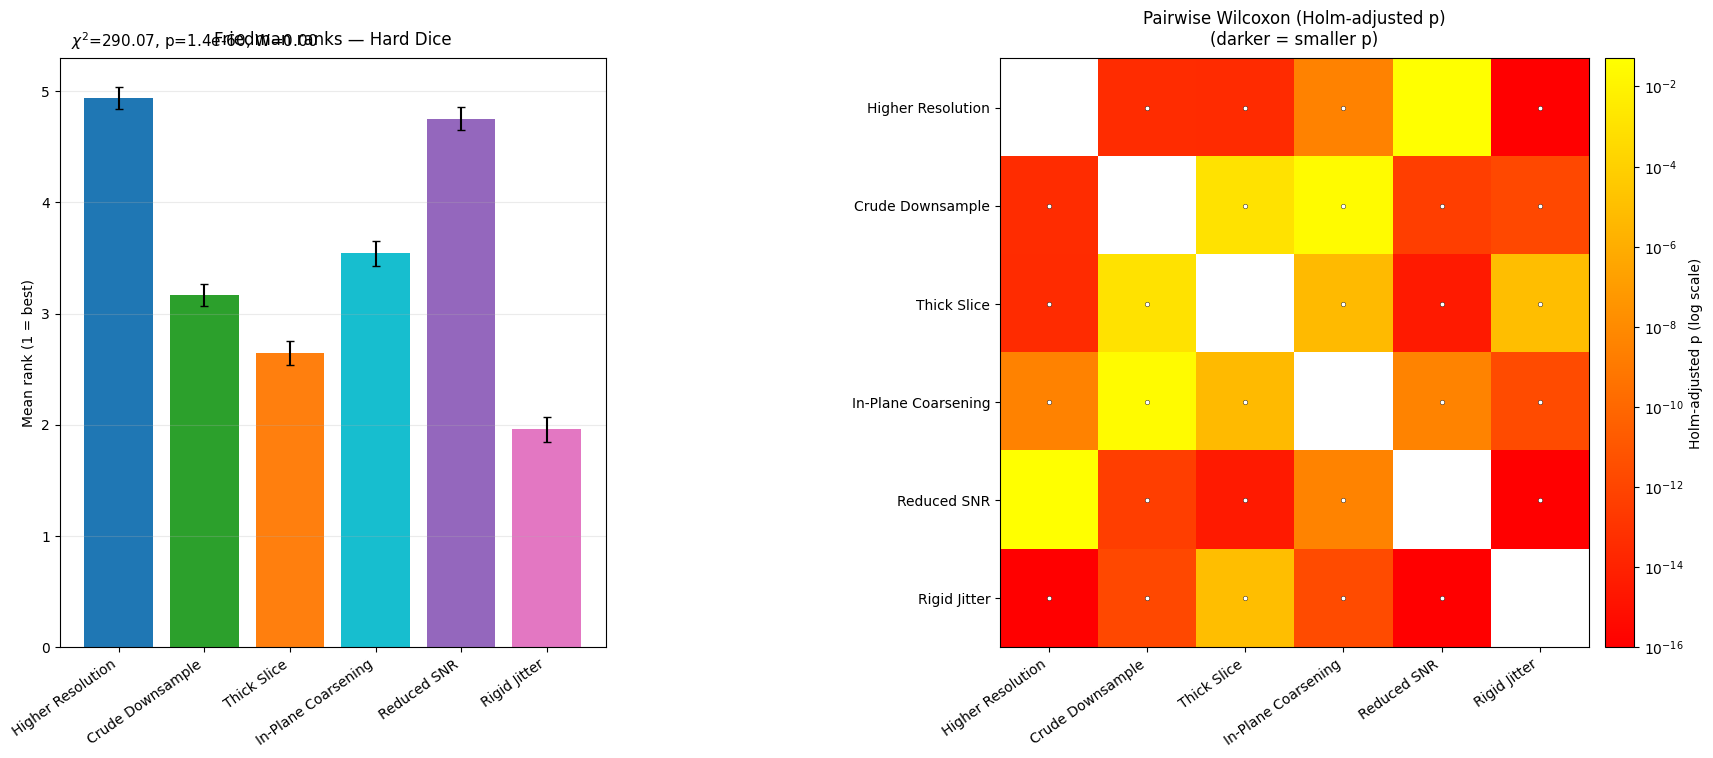

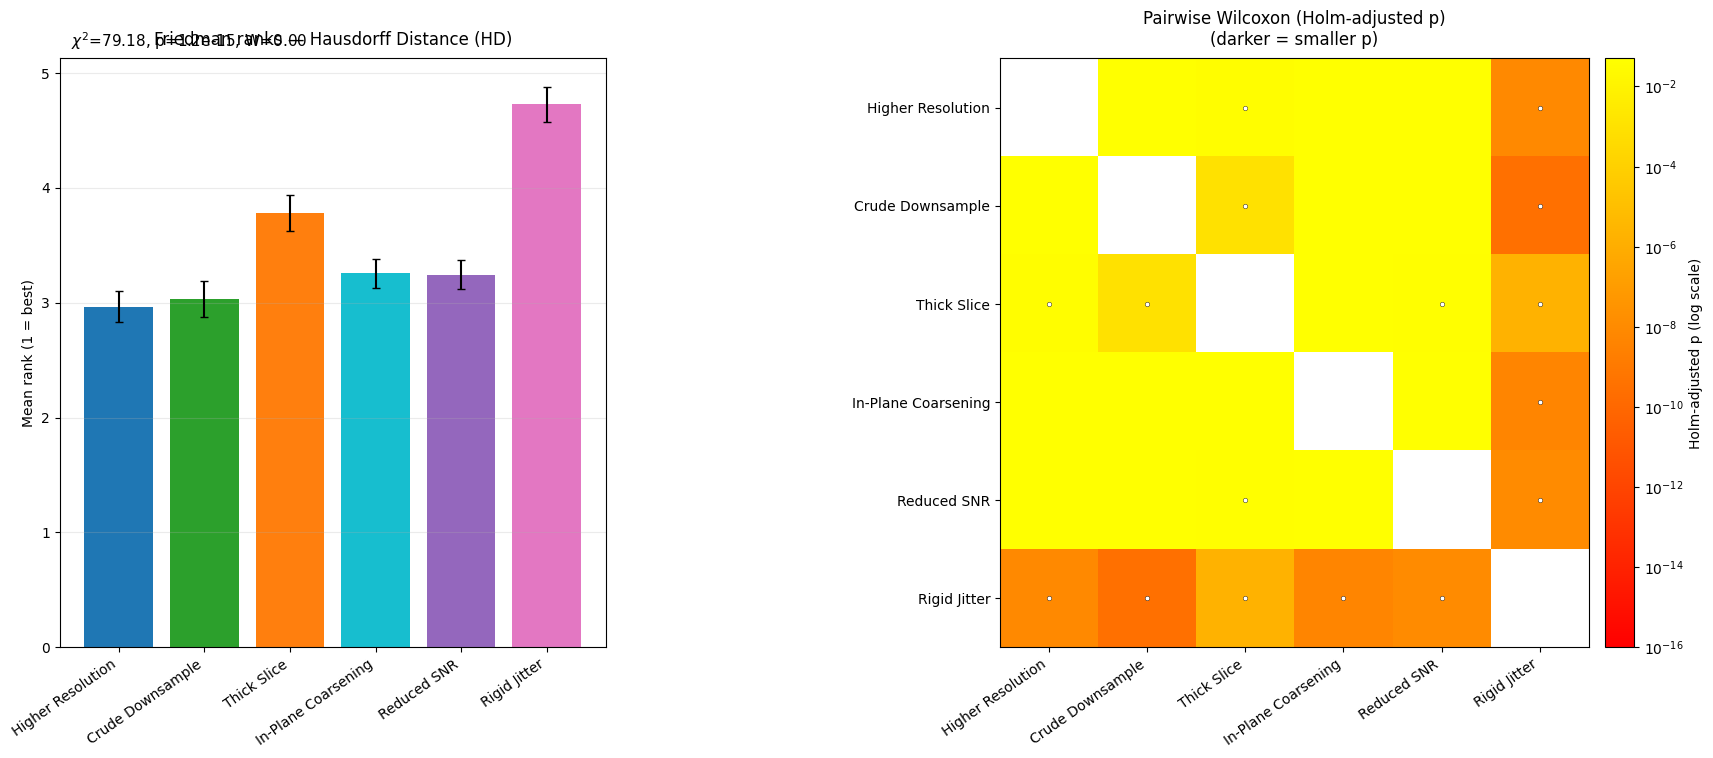

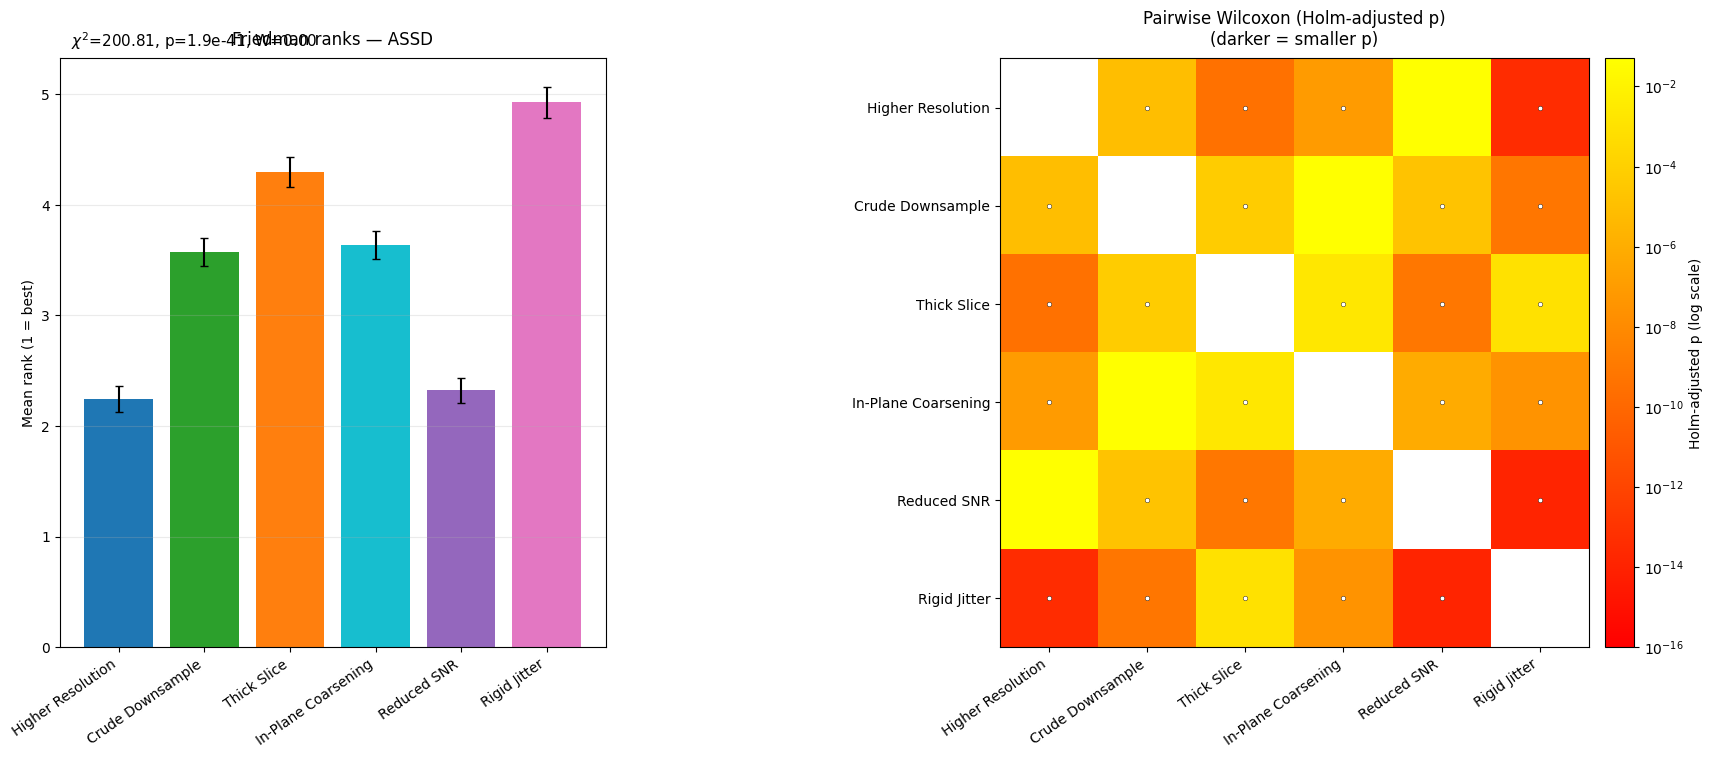

In [ ]:
# -- Clean plotting helper that matches your result dict schema exactly --
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Requested bar colors by dataset label
LEFT_COLORS = {
    "Higher Resolution":   "#1f77b4",  # blue
    "Crude Downsample":    "#2ca02c",  # green
    "Thick Slice":         "#ff7f0e",  # orange
    "In-Plane Coarsening": "#17becf",  # light blue
    "Reduced SNR":         "#9467bd",  # purple
    "Rigid Jitter":        "#e377c2",  # pink
}

def plot_friedman_visuals_gradient_resdict(
    res, metric_title="Hard Dice", cmap="autumn", figsize=(17.2, 9.2), save_path=None
):
    # res must have: tags, rank_means, rank_se, p_holm, chi2, p_friedman, kendall_w, n
    tags       = list(res["tags"])
    rank_means = np.asarray(res["rank_means"], float)
    rank_se    = np.asarray(res["rank_se"], float)
    p_holm_mat = np.asarray(res["p_holm"], float)
    chi2       = float(res.get("chi2", np.nan))
    p_f        = float(res.get("p_friedman", np.nan))
    W          = float(res.get("kendall_w", np.nan))

    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1.05, 1.55], "wspace": 0.34}
    )
    fig.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.24)

    # --- Left: mean ranks ---
    x = np.arange(len(tags))
    colors = [LEFT_COLORS.get(t, "#555555") for t in tags]
    axL.bar(x, rank_means, yerr=rank_se, capsize=3, color=colors, edgecolor="none")
    axL.set_xticks(x, tags, rotation=35, ha="right")
    axL.set_ylabel("Mean rank (1 = best)", fontsize=24)
    axL.set_title(f"Friedman ranks — {metric_title}", pad=14, fontsize=30)
    axL.text(
        0.02, 1.02, r"$\chi^2$" + f"={chi2:.2f}, p={p_f:.1e}, W={W:.2f}",
        transform=axL.transAxes, fontsize=22
    )
    axL.tick_params(axis="both", labelsize=20)
    axL.grid(True, axis="y", alpha=0.25)

    # --- Right: Holm-adjusted p (gradient heatmap) ---
    P = p_holm_mat.copy()
    # mirror lower triangle into upper for continuous field; mask diagonal
    lower = np.tril_indices_from(P, -1)
    P[lower] = P.T[lower]
    np.fill_diagonal(P, np.nan)

    vmin, vmax = 1e-16, 5e-2
    P_plot = np.where(np.isfinite(P), np.clip(P, vmin, vmax), np.nan)
    im = axR.imshow(P_plot, norm=LogNorm(vmin=vmin, vmax=vmax), cmap=cmap)

    axR.set_xticks(np.arange(len(tags))); axR.set_xticklabels(tags, rotation=35, ha="right")
    axR.set_yticks(np.arange(len(tags))); axR.set_yticklabels(tags)
    axR.set_title("Pairwise Wilcoxon (Holm-adjusted p)\n(darker = smaller p)", pad=14, fontsize=30)
    axR.tick_params(axis="both", labelsize=20)

    # subtle significance dots (p<0.05)
    for i in range(len(tags)):
        for j in range(len(tags)):
            if i == j or not np.isfinite(p_holm_mat[i, j]): 
                continue
            if p_holm_mat[i, j] < 0.05:
                axR.plot(j, i, marker="o", ms=3.2, color="white",
                         markeredgecolor="black", markeredgewidth=0.3)

    cbar = fig.colorbar(im, ax=axR, fraction=0.046, pad=0.02)
    cbar.set_label("Holm-adjusted p (log scale)", fontsize=24)
    cbar.ax.tick_params(labelsize=20)

    if save_path:
        fig.savefig(save_path, dpi=220, bbox_inches="tight"); print("Saved ->", save_path)
    plt.show()
    return fig

# ---- Call with YOUR dicts (res_hard / res_hd / res_assd) ----
_ = plot_friedman_visuals_gradient_resdict(res_hard, metric_title="Hard Dice")
_ = plot_friedman_visuals_gradient_resdict(res_hd,   metric_title="Hausdorff Distance (HD)")
_ = plot_friedman_visuals_gradient_resdict(res_assd, metric_title="ASSD")


In [ ]:
_ = plot_friedman_visuals_gradient(res_hard, metric_title="Hard Dice")
_ = plot_friedman_visuals_gradient(res_hd,   metric_title="Hausdorff Distance (HD)")
_ = plot_friedman_visuals_gradient(res_assd, metric_title="ASSD")

DEBUG keys in res: ['tags', 'n', 'rank_means', 'rank_se', 'chi2', 'p_friedman', 'kendall_w', 'p_holm']


KeyError: 'No mean ranks found and no rank matrix to derive them.\nExpected one of: mean_ranks/ranks_mean/mean_rank OR rank_matrix/ranks.'